Primero tenemos que enseñar a la maquina, en mi caso hice 3 clases -> Coche, Monitor y Zapatilla
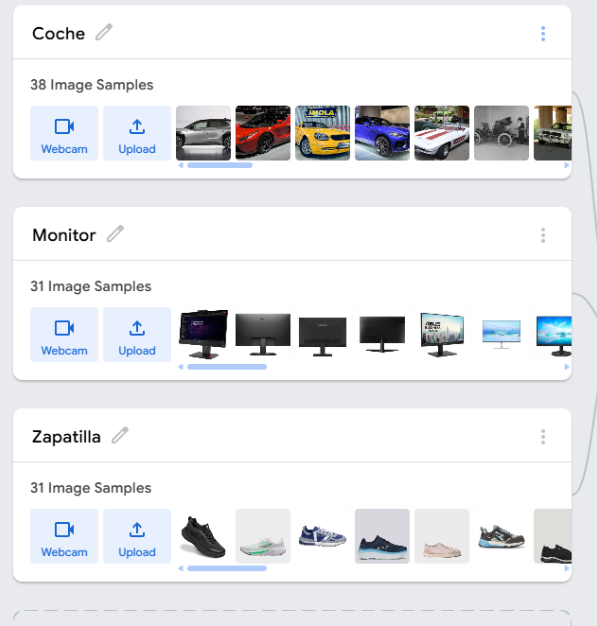

Una vez hemos insertado suficientes imágenes, ya podemos decirle a la máquina que entrene:
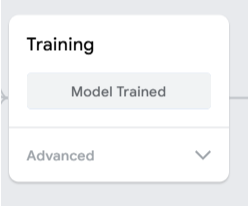

Y finalmente realizamos pruebas de las 3 clases que he creado:
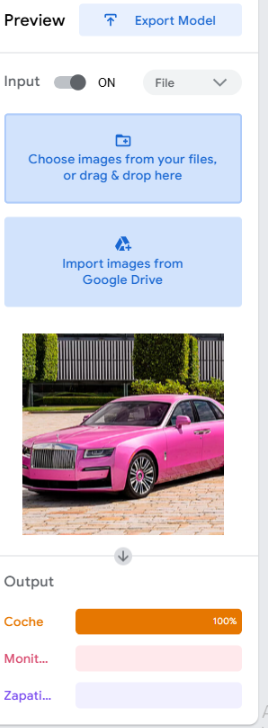
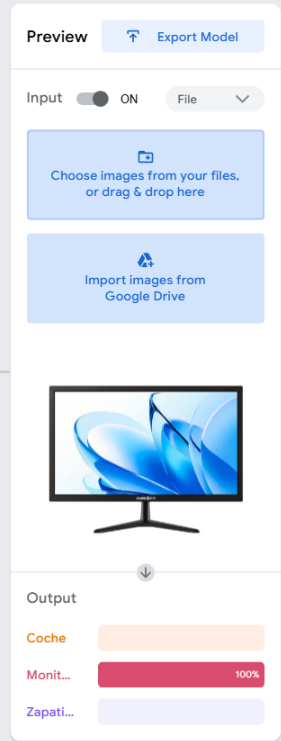
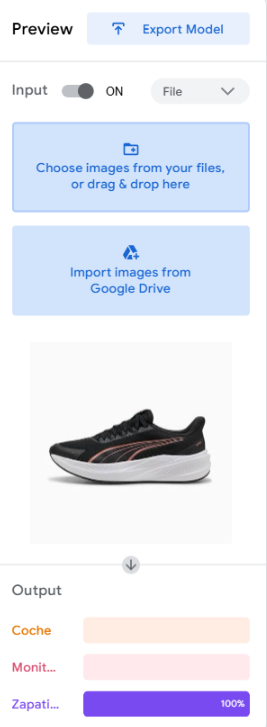

---



In [ ]:
from google.colab import files

archivos = files.upload()

Saving metadata.json to metadata.json
Saving model.json to model.json
Saving weights.bin to weights.bin


In [ ]:
%%writefile index.html

<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Clasificador con Teachable Machine</title>

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>

    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>
</head>

<body>

    <h1>Clasificador de imágenes</h1>

    <button type="button" onclick="init()">Iniciar cámara</button>

    <div id="webcam-container"></div>

    <div id="label-container"></div>

    <script>
        const URL = "./";

        let model;
        let webcam;
        let labelContainer;
        let maxPredictions;

        async function init() {

            const modelURL = URL + "model.json";
            const metadataURL = URL + "metadata.json";

            model = await tmImage.load(modelURL, metadataURL);

            maxPredictions = model.getTotalClasses();

            const flip = true;

            webcam = new tmImage.Webcam(300, 300, flip);

            await webcam.setup();
            await webcam.play();

            window.requestAnimationFrame(loop);

            document.getElementById("webcam-container").appendChild(webcam.canvas);

            labelContainer = document.getElementById("label-container");

            for (let i = 0; i < maxPredictions; i++) {
                labelContainer.appendChild(document.createElement("div"));
            }
        }

        async function loop() {

            webcam.update();

            await predict();

            window.requestAnimationFrame(loop);
        }

        async function predict() {

            const prediction = await model.predict(webcam.canvas);

            for (let i = 0; i < maxPredictions; i++) {

                labelContainer.childNodes[i].innerHTML =
                    prediction[i].className +
                    ": " +
                    (prediction[i].probability * 100).toFixed(2) +
                    "%";
            }
        }
    </script>

</body>
</html>

Writing index.html


In [ ]:
import portpicker

port = portpicker.pick_unused_port()

print("Puerto:", port)

Puerto: 41211


In [ ]:
get_ipython().system_raw(
    f"python3 -m http.server {port} --directory /content > /tmp/server.log 2>&1 &"
)

In [ ]:
!cat /tmp/server.log

In [ ]:
!curl -I http://localhost:{port}/index.html

HTTP/1.0 200 OK
Server: SimpleHTTP/0.6 Python/3.13.16
Date: Wed, 07 Oct 2026 01:11:42 GMT
Content-type: text/html
Content-Length: 217
Last-Modified: Wed, 07 Oct 2026 01:04:56 GMT



In [ ]:
from google.colab import output

url = output.eval_js(f"google.colab.kernel.proxyPort({port})")
print(url)

https://41211-m-s-kkb-usw1b1-15x3oqpzi2c9a-b.us-west1-1.prod.colab.dev


In [ ]:
%%writefile index.html

<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Clasificador de Teachable Machine</title>

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>

    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>
</head>

<body>

    <h1>Clasificador de imágenes</h1>

    <button type="button" onclick="init()">Iniciar cámara</button>

    <div id="webcam-container"></div>

    <div id="label-container"></div>

    <script>
        const URL = "./";

        let model;
        let webcam;
        let labelContainer;
        let maxPredictions;

        async function init() {

            const modelURL = URL + "model.json";
            const metadataURL = URL + "metadata.json";

            model = await tmImage.load(modelURL, metadataURL);

            maxPredictions = model.getTotalClasses();

            webcam = new tmImage.Webcam(300, 300, true);

            await webcam.setup();
            await webcam.play();

            window.requestAnimationFrame(loop);

            document
                .getElementById("webcam-container")
                .appendChild(webcam.canvas);

            labelContainer = document.getElementById("label-container");

            for (let i = 0; i < maxPredictions; i++) {
                labelContainer.appendChild(document.createElement("div"));
            }
        }

        async function loop() {

            webcam.update();

            await predict();

            window.requestAnimationFrame(loop);
        }

        async function predict() {

            const prediction = await model.predict(webcam.canvas);

            for (let i = 0; i < maxPredictions; i++) {

                labelContainer.childNodes[i].innerHTML =
                    prediction[i].className +
                    ": " +
                    (prediction[i].probability * 100).toFixed(2) +
                    "%";
            }
        }
    </script>

</body>
</html>

Overwriting index.html


In [ ]:
%%writefile index.html

<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Clasificador de imágenes</title>

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>

    <style>
        body {
            font-family: Arial, sans-serif;
            text-align: center;
            margin: 40px;
        }

        #preview {
            max-width: 400px;
            max-height: 400px;
            margin-top: 20px;
        }

        #label-container {
            margin-top: 20px;
            font-size: 20px;
        }
    </style>
</head>

<body>

    <h1>Clasificador de imágenes</h1>

    <input type="file" id="image-input" accept="image/*">

    <br>

    <img id="preview" style="display: none;">

    <div id="label-container"></div>

    <script>
        const URL = "./";

        let model;
        let maxPredictions;

        async function loadModel() {

            const modelURL = URL + "model.json";
            const metadataURL = URL + "metadata.json";

            model = await tmImage.load(modelURL, metadataURL);

            maxPredictions = model.getTotalClasses();

            console.log("Modelo cargado");
        }

        async function predict(image) {

            const prediction = await model.predict(image);

            const labelContainer = document.getElementById("label-container");

            labelContainer.innerHTML = "";

            for (let i = 0; i < maxPredictions; i++) {

                const resultado = document.createElement("div");

                resultado.innerHTML =
                    prediction[i].className +
                    ": " +
                    (prediction[i].probability * 100).toFixed(2) +
                    "%";

                labelContainer.appendChild(resultado);
            }
        }

        document.getElementById("image-input").addEventListener("change", function(event) {

            const file = event.target.files[0];

            if (file) {

                const image = document.getElementById("preview");

                image.src = URL.createObjectURL(file);

                image.style.display = "block";

                image.onload = function() {
                    predict(image);
                };
            }
        });

        loadModel();
    </script>

</body>
</html>

Overwriting index.html


In [ ]:
%%writefile index.html

<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Clasificador de imágenes</title>

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>

    <style>
        body {
            font-family: Arial, sans-serif;
            text-align: center;
            margin: 40px;
        }

        #preview {
            max-width: 400px;
            max-height: 400px;
            margin-top: 20px;
        }

        #label-container {
            margin-top: 20px;
            font-size: 20px;
        }
    </style>
</head>

<body>

    <h1>Clasificador de imágenes</h1>

    <input type="file" id="image-input" accept="image/*">

    <br>

    <img id="preview" style="display: none;">

    <div id="label-container">
        Cargando modelo...
    </div>

    <script>
        const MODEL_URL = "./";

        let model;
        let maxPredictions;

        async function loadModel() {

            const modelURL = MODEL_URL + "model.json";
            const metadataURL = MODEL_URL + "metadata.json";

            model = await tmImage.load(modelURL, metadataURL);

            maxPredictions = model.getTotalClasses();

            document.getElementById("label-container").innerHTML =
                "Modelo cargado. Selecciona una imagen.";
        }

        async function predict(image) {

            const prediction = await model.predict(image);

            const labelContainer =
                document.getElementById("label-container");

            labelContainer.innerHTML = "";

            for (let i = 0; i < maxPredictions; i++) {

                const resultado = document.createElement("div");

                resultado.innerHTML =
                    prediction[i].className +
                    ": " +
                    (prediction[i].probability * 100).toFixed(2) +
                    "%";

                labelContainer.appendChild(resultado);
            }
        }

        document.getElementById("image-input").addEventListener("change", function(event) {

            const file = event.target.files[0];

            if (file) {

                const image = document.getElementById("preview");

                image.src = window.URL.createObjectURL(file);

                image.style.display = "block";

                image.onload = function() {
                    predict(image);
                };
            }
        });

        loadModel();
    </script>

</body>
</html>

Overwriting index.html


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'weights.bin', 'index.html', 'model.json', 'metadata.json', 'sample_data']


In [ ]:
from google.colab import files

files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("model.json")
files.download("metadata.json")
files.download("weights.bin")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import os
import shutil

os.makedirs("/content/clasificador/modelo", exist_ok=True)

shutil.copy("/content/model.json", "/content/clasificador/modelo/model.json")
shutil.copy("/content/metadata.json", "/content/clasificador/modelo/metadata.json")
shutil.copy("/content/weights.bin", "/content/clasificador/modelo/weights.bin")

print("Estructura creada correctamente")

Estructura creada correctamente


In [38]:
!find /content/clasificador -type f

/content/clasificador/modelo/weights.bin
/content/clasificador/modelo/model.json
/content/clasificador/modelo/metadata.json


In [39]:
%%writefile /content/clasificador/index.html

<!DOCTYPE html>
<html lang="es">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Clasificador de imágenes</title>

    <link rel="stylesheet" href="styles.css">

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@latest/dist/tf.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@latest/dist/teachablemachine-image.min.js"></script>
</head>

<body>

    <main class="container">

        <h1>Clasificador de imágenes</h1>

        <p id="status">
            Cargando modelo...
        </p>

        <section class="controls">

            <button type="button" id="start-button">
                Iniciar cámara
            </button>

            <button type="button" id="stop-button">
                Parar cámara
            </button>

        </section>

        <section class="threshold-section">

            <label for="threshold">
                Coincidencia mínima:
                <span id="threshold-value">70</span>%
            </label>

            <input
                type="range"
                id="threshold"
                min="1"
                max="100"
                value="70"
            >

        </section>

        <section class="camera-section">

            <div id="webcam-container"></div>

        </section>

        <section class="upload-section">

            <h2>Subir una imagen</h2>

            <input
                type="file"
                id="image-input"
                accept="image/*"
            >

            <br>

            <img
                id="preview"
                alt="Imagen seleccionada"
            >

            <br>

            <button type="button" id="predict-button">
                Calificar imagen
            </button>

        </section>

        <section class="result-section">

            <h2>Resultado</h2>

            <div id="result">
                Todavía no hay ninguna clasificación.
            </div>

        </section>

        <section class="history-section">

            <h2>Histórico de resultados</h2>

            <button type="button" id="clear-history-button">
                Borrar histórico
            </button>

            <div id="history"></div>

        </section>

    </main>

    <script src="app.js"></script>

</body>

</html>

Writing /content/clasificador/index.html
